In [13]:
import seaborn as sns
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report
import pandas as pd
print(sklearn.__version__)   # needs 1.4+ for root_mean_squared_error
tips = sns.load_dataset("tips")
print(tips.shape)            # (244, 7)

1.9.0
(244, 7)


In [14]:
# Download at home and bring the CSV
! curl -0 https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv  > tips.csv

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
100   9729 100   9729   0      0  50187      0                              0


In [15]:
tips = pd.read_csv("tips.csv")   # fallback

# Load and explore

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

print(tips.shape)
tips.head()

(244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


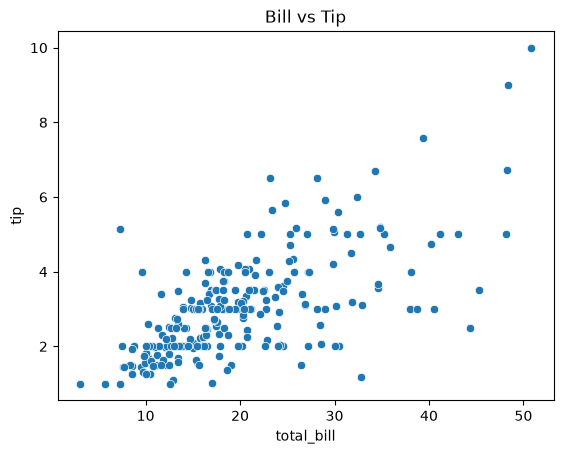

In [17]:
sns.scatterplot(data=tips, x="total_bill", y="tip")
plt.title("Bill vs Tip")
plt.show()

# Train linear regression

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

tip ≈ 0.9252 + 0.1070 · total_bill
RMSE : $0.75
R²   : 0.54


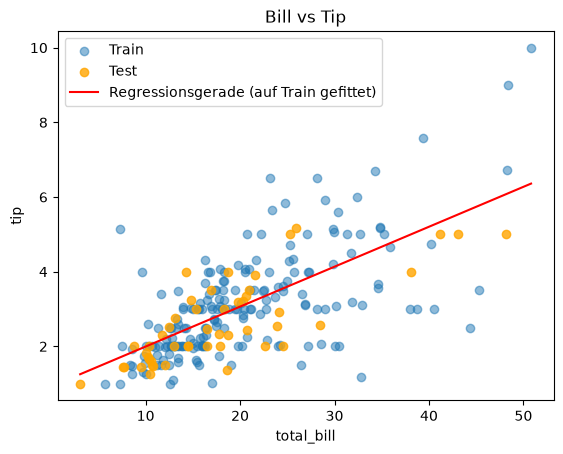

In [26]:
X_bill = tips[["total_bill"]]
y = tips["tip"]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bill, y, test_size=0.2, random_state=42
)

model_bill = LinearRegression()
model_bill.fit(Xb_train, yb_train)

yb_pred = model_bill.predict(Xb_test)
rmse_bill = np.sqrt(mean_squared_error(yb_test, yb_pred))
r2_bill = r2_score(yb_test, yb_pred)

print(f"tip ≈ {model_bill.intercept_:.4f} + {model_bill.coef_[0]:.4f} · total_bill")
print(f"RMSE : ${rmse_bill:.2f}")
print(f"R²   : {r2_bill:.2f}")

plt.scatter(Xb_train["total_bill"], yb_train, alpha=0.5, label="Train")
plt.scatter(Xb_test["total_bill"], yb_test, alpha=0.8, color="orange", label="Test")
line_x = pd.DataFrame({"total_bill": np.linspace(tips["total_bill"].min(), tips["total_bill"].max(), 100)})
plt.plot(line_x["total_bill"], model_bill.predict(line_x), color="red", label="Regressionsgerade (auf Train gefittet)")
plt.xlabel("total_bill")
plt.ylabel("tip")
plt.title("Bill vs Tip")
plt.legend()
plt.show()

In [29]:


X = tips[["total_bill", "size"]]
y = tips["tip"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE : ${rmse:.2f}")
print(f"R²   : {r2:.2f}")


RMSE : $0.81
R²   : 0.48


## Regressions-Metriken: RMSE und R²

**RMSE (Root Mean Squared Error)** misst, wie weit die Vorhersagen im Durchschnitt von den tatsächlichen Werten entfernt sind:

$$\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

- Die Fehler werden **quadriert**, bevor gemittelt wird — große Ausreißer fallen dadurch stärker ins Gewicht.
- Durch die Wurzel hat der RMSE dieselbe **Einheit wie die Zielvariable** (hier: Dollar Trinkgeld). Ein RMSE von 1.0 heißt also: die Vorhersage liegt typischerweise etwa 1 $ daneben.
- Je **kleiner**, desto besser; 0 wäre eine perfekte Vorhersage.

**R² (Bestimmtheitsmaß / coefficient of determination)** gibt an, welcher **Anteil der Varianz** der Zielvariable durch das Modell erklärt wird:

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

- Der Bruch vergleicht die Fehler des Modells mit den Fehlern eines naiven Baseline-Modells, das **immer den Mittelwert** $\bar{y}$ vorhersagt.
- **R² = 1**: perfekte Vorhersage. **R² = 0**: das Modell ist nicht besser als der Mittelwert. **R² < 0** ist möglich — das Modell ist dann sogar *schlechter* als die Mittelwert-Baseline.
- R² ist **einheitenlos** und damit gut zum Vergleichen von Modellen; R

In [19]:
for name, coef in zip(X.columns, model.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

  total_bill: 0.0909
  size: 0.2650
Intercept: 0.5681


 $$\hat{\text{tip}} = 0.5681 + 0.0909 \cdot \text{total\_bill} + 0.2650 \cdot \text{size}$$

In [28]:
tips["is_dinner"] = (tips["time"] == "Dinner").astype(int)
tips["bill_per_person"] = tips["total_bill"] / tips["size"]

X2 = tips[["total_bill", "size", "is_dinner", "bill_per_person"]]
y2 = tips["tip"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)

rmse2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
r2_2 = r2_score(y2_test, y2_pred)

print(f"RMSE: ${rmse2:.2f}  was ${rmse:.2f}")
print(f"R²  : {r2_2:.2f}  was {r2:.2f}")

RMSE: $0.83  was $0.81
R²  : 0.45  was 0.48


# Breath Cancer

In [31]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()
print("Target names:", data.target_names)
print("Shape:", data.data.shape)

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target
print(df["target"].value_counts())


Target names: ['malignant' 'benign']
Shape: (569, 30)
target
1    357
0    212
Name: count, dtype: int64


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LogisticRegression(max_iter=10000)
lr.fit(X_train, y_train)

print(f"Logistic Regression: {accuracy_score(y_test, lr.predict(X_test)):.2%}")

Logistic Regression: 95.61%


In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gbt = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbt.fit(X_train, y_train)
gbt_pred = gbt.predict(X_test)

print(f"Gradient Boosting: {accuracy_score(y_test, gbt_pred):.2%}")

Gradient Boosting: 95.61%


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, gbt_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



- **Precision** — von allen Fällen, die wir als bösartig eingestuft haben: wie viele waren tatsächlich bösartig?
- **Recall** — von allen tatsächlich bösartigen Fällen: wie viele haben wir erwischt?
- **F1** — die Balance zwischen den beiden
- **Support** — Anzahl der echten Fälle jeder Klasse im Test-Set

